In [ ]:
import pandas as pd
import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,standardization,Grafico_Before_After_Standardization,Grafico_Tre_Valori,evaluate_Model, encode_labels, ConfusionMatrix# type: ignore
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV  
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
import xgboost, sklearn
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [5]:

# Prepara i dati
X_train, X_test, y_train, y_test = prepareTrainingSet3Sec()

# Converti le etichette delle classi in valori numerici
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test)
y_train = label_encoder.fit_transform(y_train)

# Creare il modello Logistic
model = XGBClassifier(learning_rate=0.01, n_estimators=600, max_depth=9, min_child_weight=25, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
before_standardization= accuracy_score(y_test, y_pred)

evaluate_Model(y_test, y_pred, y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.8478
Precision: 0.8465
Recall: 0.8484
F1-score: 0.8464
F2-score: 0.8474
---------STATISTICHE TRAING----------
Accuratezza: 0.9441
Precision: 0.9444
Recall: 0.9440
F1-score: 0.9440
F2-score: 0.9440


In [6]:


# Prepara i dati
X_train, X_test, y_train, y_test = prepareTrainingSet3Sec()

# Converti le etichette delle classi in valori numerici
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test)
y_train = label_encoder.fit_transform(y_train)

# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test = standardization(X_train, X_test)

# Creare il modello Logistic
model = XGBClassifier(learning_rate=0.01, n_estimators=600, max_depth=9, min_child_weight=25, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)
after_standardization= accuracy_score(y_test, y_pred)


evaluate_Model(y_test, y_pred, y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.8509
Precision: 0.8497
Recall: 0.8513
F1-score: 0.8495
F2-score: 0.8503
---------STATISTICHE TRAING----------
Accuratezza: 0.9439
Precision: 0.9443
Recall: 0.9439
F1-score: 0.9439
F2-score: 0.9439


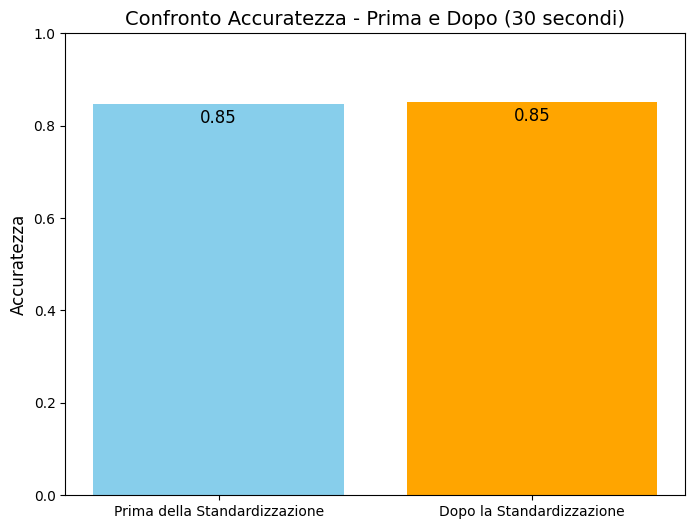

In [7]:
Grafico_Before_After_Standardization(before_standardization, after_standardization)

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Caricare il dataset
DATASET_CSV = "Data/features_3_sec.csv"
df = pd.read_csv(DATASET_CSV)

# Separare features e target
feature_cols = [col for col in df.columns if col not in ['filename', 'label']]
X = df[feature_cols].values.astype(float)
y = df['label'].values

# Suddividere in training e test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test)
y_train = label_encoder.fit_transform(y_train)

# Definire la griglia degli iperparametri
param_grid = {
    'n_estimators': [100, 200],  # Numero di alberi
    'max_depth': [3, 5, 7],  # Profondità massima degli alberi
    'learning_rate': [ 0.1, 0.3],  # Tasso di apprendimento
    
}

# Creare il modello
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Eseguire la Grid Search con cross-validation
grid_search = GridSearchCV(model, param_grid, scoring='accuracy', cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Stampare i migliori parametri
print("Migliori parametri trovati:", grid_search.best_params_)

# Valutare il miglior modello
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

valid_models = []
for params in grid_search.cv_results_['params']:
    model.set_params(**params)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    if abs(train_accuracy - test_accuracy) <= train_accuracy*0.1 and train_accuracy < 0.99:
        valid_models.append((model, params, train_accuracy, test_accuracy))

# Trova il miglior modello tra quelli validi
if valid_models:
    best_model, best_params, best_train_accuracy, best_test_accuracy = max(valid_models, key=lambda x: x[3])
    XGboost= float(best_test_accuracy)

    print(f"Training Accuracy: {best_train_accuracy}")
    print(f"Testing Accuracy: {best_test_accuracy}")
    print(f"Best Parameters: {best_params}")
    print("La differenza tra l'accuracy di training e di test è entro il 10%.")
else:
    print("Nessun modello ha una differenza di accuracy entro il 10%.")

C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\david\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
Grafico_Tre_Valori(before_standardization, after_standardization, XGboost)